In [ ]:
!pip install -q pandas sqlalchemy kaggle

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text
import os

In [ ]:
import kagglehub

path = kagglehub.dataset_download("rish59/financial-statements-of-major-companies2009-2023")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'financial-statements-of-major-companies2009-2023' dataset.
Path to dataset files: /kaggle/input/financial-statements-of-major-companies2009-2023


In [ ]:
for f in os.listdir(path):
    print(f)

Financial Statements.csv


In [ ]:
csv_filename = os.listdir(path)[0]
csv_path = os.path.join(path, csv_filename)

df_raw = pd.read_csv(csv_path)
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap(in B USD)                 160 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

In [ ]:
df_raw.head(10)

,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
0,2022,AAPL,IT,2066.94,394328.0,170782.0,99803.0,6.1100,130541.0,50672.0,...,0.8794,2.3695,196.9589,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028
1,2021,AAPL,IT,2913.28,365817.0,152836.0,94680.0,5.6100,120233.0,63090.0,...,1.0746,1.9768,150.0713,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979
2,2020,AAPL,IT,2255.97,274515.0,104956.0,57411.0,3.2800,77344.0,65339.0,...,1.3636,1.7208,87.8664,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336
3,2019,AAPL,IT,1304.76,260174.0,98392.0,55256.0,2.9700,76477.0,90488.0,...,1.5401,1.1940,61.0645,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122
4,2018,AAPL,IT,748.54,265595.0,101839.0,59531.0,2.9800,81801.0,107147.0,...,1.1329,1.0685,55.5601,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426
5,2017,AAPL,IT,868.87,229234.0,88186.0,48351.0,2.3025,71501.0,134047.0,...,1.2761,0.8630,36.0702,12.8826,20.9082,21.0924,0.0330,36.0702,123000,2.1301
6,2016,AAPL,IT,617.59,215639.0,84263.0,45687.0,2.0775,70529.0,128249.0,...,1.3527,0.6786,35.6237,14.2024,22.4312,21.1868,-0.5901,38.1906,116000,1.2616
7,2015,AAPL,IT,586.86,233715.0,93626.0,53394.0,2.3050,82487.0,119355.0,...,1.1088,0.5390,44.7355,18.3899,30.9201,22.8458,0.9743,48.3878,110000,0.1186
8,2014,AAPL,IT,647.36,182795.0,70537.0,39510.0,1.6125,60449.0,111547.0,...,1.0801,0.3164,35.4201,17.0420,28.1142,21.6144,0.3032,38.4380,97000,1.6222
9,2013,AAPL,IT,504.79,170910.0,64304.0,37037.0,1.4200,55756.0,123549.0,...,1.6786,0.1373,29.9776,17.8923,26.3592,21.6705,0.1363,31.4425,84400,1.4648


In [ ]:
df_raw.columns = df_raw.columns.str.strip()

In [ ]:
null_rows = df_raw[df_raw.isnull().any(axis=1)]
null_rows.head()

,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
51,2014,PYPL,FinTech,NaN,8025.0,4218.0,419.0,0.34,1784.0,8248.0,...,1.3224,0.1325,5.08,1.9118,5.08,5.2212,0.103,8.5458,15800,1.6222


In [ ]:
duplicate_df = df_raw[df_raw.duplicated()]
duplicate_df.head()

,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)


In [ ]:
conn = sqlite3.connect(':memory:')
df_raw.to_sql('Financial Report', conn, index=False, if_exists='replace')
print(pd.read_sql_query("SELECT * FROM 'Financial Report' LIMIT 1;", conn).columns.tolist())

['Year', 'Company', 'Category', 'Market Cap(in B USD)', 'Revenue', 'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA', 'Share Holder Equity', 'Cash Flow from Operating', 'Cash Flow from Investing', 'Cash Flow from Financial Activities', 'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI', 'Net Profit Margin', 'Free Cash Flow per Share', 'Return on Tangible Equity', 'Number of Employees', 'Inflation Rate(in US)']


# Year-over-Year Revenue Growth

Which companies grew revenue fastest (and slowest) year over year, and how does growth compare across the group over time?

In [ ]:
sql_query1 = """
SELECT
    Company AS company,
    Year AS year,
    Revenue AS revenue,
    LAG(Revenue) OVER (PARTITION BY Company ORDER BY Year) AS prev_year_revenue,
    ROUND((Revenue - LAG(Revenue) OVER (PARTITION BY Company ORDER BY Year)) * 1.0
        / LAG(Revenue) OVER (PARTITION BY Company ORDER BY Year), 4) * 100 AS yoy_growth
FROM 'Financial Report'
WHERE Year BETWEEN 2009 AND 2022
ORDER BY Company, Year;
"""
yoy_growth_df = pd.read_sql_query(sql_query1, conn)
yoy_growth_df.head(20).style.format({
    'revenue': '{:,.2f}',
    'prev_year_revenue': '{:,.2f}',
    'yoy_growth': '{:,.2f}%'
})

,company,year,revenue,prev_year_revenue,yoy_growth
0,AAPL,2009,"42,905.00",nan,nan%
1,AAPL,2010,"65,225.00","42,905.00",52.02%
2,AAPL,2011,"108,249.00","65,225.00",65.96%
3,AAPL,2012,"156,508.00","108,249.00",44.58%
4,AAPL,2013,"170,910.00","156,508.00",9.20%
5,AAPL,2014,"182,795.00","170,910.00",6.95%
6,AAPL,2015,"233,715.00","182,795.00",27.86%
7,AAPL,2016,"215,639.00","233,715.00",-7.73%
8,AAPL,2017,"229,234.00","215,639.00",6.30%
9,AAPL,2018,"265,595.00","229,234.00",15.86%


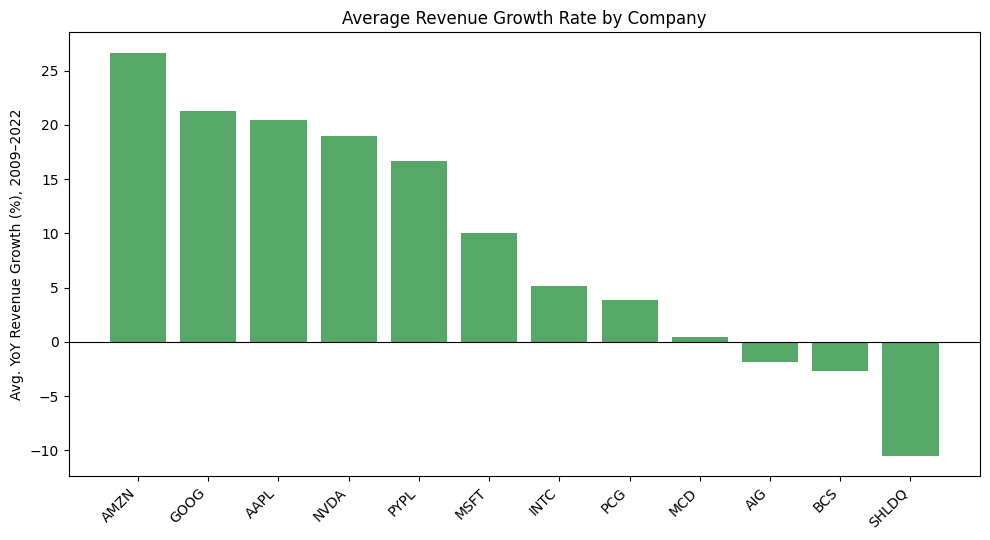

In [ ]:
avg_yoy = yoy_growth_df.dropna(subset=['yoy_growth']).groupby('company')['yoy_growth'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(avg_yoy.index, avg_yoy.values, color='#55A868')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Avg. YoY Revenue Growth (%), 2009–2022')
ax.set_title('Average Revenue Growth Rate by Company')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Company Size vs. Profitability Rank

Are the biggest companies by revenue also the most profitable ones?

In [ ]:
sql_query2 = """
SELECT
    Company AS company,
    Year AS year,
    Revenue AS revenue,
    "Net Income" AS net_income,
    ROUND(("Net Income" * 1.0) / Revenue * 100, 4) AS net_margin,
    RANK() OVER (PARTITION BY Year ORDER BY Revenue DESC) AS size_rank,
    RANK() OVER (PARTITION BY Year ORDER BY ("Net Income" * 1.0) / Revenue DESC) AS profitability_rank
FROM 'Financial Report'
WHERE Year BETWEEN 2009 AND 2022
ORDER BY Year, size_rank;
"""

profitability_rank = pd.read_sql_query(sql_query2, conn)

profitability_rank.head(20).style.format({
    'revenue': '{:,.2f}',
    'net_income': '{:,.2f}',
    'net_margin': '{:,.2f}'
})

,company,year,revenue,net_income,net_margin,size_rank,profitability_rank
0,AIG,2009,"75,447.00","-12,244.00",-16.23,1,11
1,MSFT,2009,"58,437.00","14,569.00",24.93,2,2
2,SHLDQ,2009,"46,770.00",53.00,0.11,3,9
3,BCS,2009,"45,992.04","5,497.87",11.95,4,6
4,AAPL,2009,"42,905.00","8,235.00",19.19,5,4
5,INTC,2009,"35,127.00","4,369.00",12.44,6,5
6,AMZN,2009,"24,509.00",902.00,3.68,7,8
7,GOOG,2009,"23,651.00","6,520.00",27.57,8,1
8,MCD,2009,"22,744.70","4,551.00",20.01,9,3
9,PCG,2009,"13,399.00","1,220.00",9.11,10,7


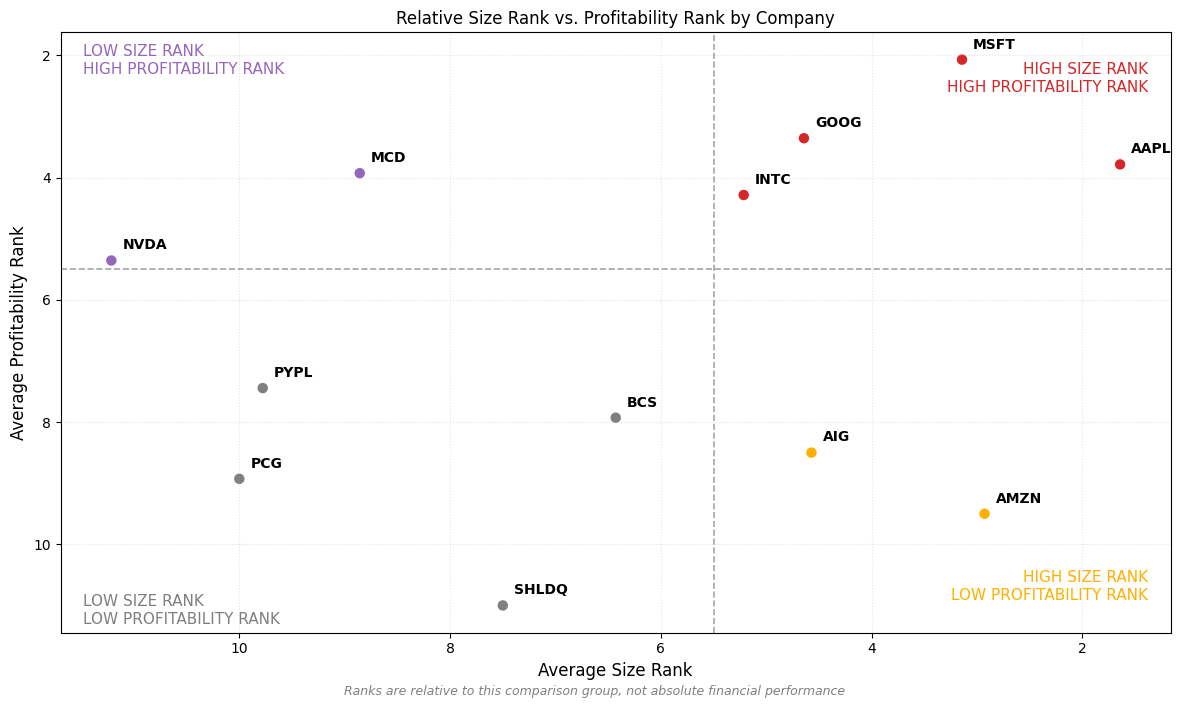

In [ ]:
# Average the raw ranks per company (across all years the company existed)
company_avg = (
    profitability_rank
    .groupby("company", as_index=False)[["size_rank", "profitability_rank"]]
    .mean()
)

# Calculating Median Lines (on the original 1-10 rank scale)
size_median = 5.5
profitability_median = 5.5

# For each category, automatically calculates the dot color based on median values
# NOTE: lower rank number = better, so "high" now means rank <= median
def get_color(row):
    if row["size_rank"] <= size_median and row["profitability_rank"] <= profitability_median:
        return "#d62728"       # High Revenue + High Profitability
    elif row["size_rank"] <= size_median:
        return "#ffb000"       # High Revenue + Low Profitability
    elif row["profitability_rank"] <= profitability_median:
        return "#9467bd"      # Low Revenue + High Profitability
    else:
        return "#7f7f7f"       # Low Revenue + Low Profitability


company_avg["color"] = company_avg.apply(get_color, axis=1)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    company_avg["size_rank"],
    company_avg["profitability_rank"],
    c=company_avg["color"],
    linewidth=1.5
)


# Dot Labels
for index, row in company_avg.iterrows():
    ax.annotate(
        row["company"],
        (row["size_rank"], row["profitability_rank"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# Quadrant Identifiers
ax.text(
    0.98, 0.95,
    "HIGH SIZE RANK\nHIGH PROFITABILITY RANK",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    color="#d62728"
)

ax.text(
    0.02, 0.98,
    "LOW SIZE RANK\nHIGH PROFITABILITY RANK",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    color="#9467bd"
)

ax.text(
    0.98, 0.05,
    "HIGH SIZE RANK\nLOW PROFITABILITY RANK",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    color="#ffb000"
)

ax.text(
    0.02, 0.01,
    "LOW SIZE RANK\nLOW PROFITABILITY RANK",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
    color="#7f7f7f"
)

#Quandrant boundaries
ax.axvline(
    size_median,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)

ax.axhline(
    profitability_median,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)

ax.set_title("Relative Size Rank vs. Profitability Rank by Company")
fig.text(0.5, 0.00, "Ranks are relative to this comparison group, not absolute financial performance",
          ha="center", fontsize=9, style="italic", color="gray")
ax.set_xlabel("Average Size Rank", fontsize=12)
ax.set_ylabel("Average Profitability Rank", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.35)

# Invert the axes so rank 1 (best) sits on the "high" side and rank 10 (worst) on the "low" side
ax.invert_xaxis()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Top right (red) — "Big and doing well"
These companies are both bigger and more profitable than the typical company in this group. They're the group's strongest all-around performers — MSFT, GOOG, INTC, and AAPL.

Top left (purple) — "Small but efficient"
These companies are smaller than most in the group, but they're more profitable than most. Think of it as being lean and squeezing out strong profit even without being one of the bigger players — MCD and NVDA.

Bottom right (orange) — "Big but struggling to turn it into profit"
These companies are bigger than most in the group, but their profitability lags behind. Size alone hasn't translated into strong profit margins — BCS, AIG, and AMZN.

Bottom left (gray) — "Smaller and less profitable, relatively speaking"
These companies are both smaller and less profitable than the typical company in this group — PYPL, PCG, and SHLDQ. Important: this is only compared to the other companies in this specific dataset. It doesn't mean these are bad or failing companies in the real world — just that, within this particular comparison set, they rank lower on both measures.

# Return on Equity, Assets, and Investment

Which companies generate the most return per dollar of equity, assets, and invested capital?

In [ ]:
sql_query3 = """
SELECT
    Company AS company,
    Year AS year,
    ROE AS roe,
    ROA AS roa,
    ROI AS roi,
    RANK() OVER (PARTITION BY Year ORDER BY ROE DESC) AS roe_rank,
    RANK() OVER (PARTITION BY Year ORDER BY ROA DESC) AS roa_rank,
    RANK() OVER (PARTITION BY Year ORDER BY ROI DESC) AS roi_rank
FROM 'Financial Report'
WHERE Year BETWEEN 2009 AND 2022
ORDER BY Year, roe_rank;
"""
efficiency_df = pd.read_sql_query(sql_query3, conn)
efficiency_df.head(20).style.format({
    'roe': '{:,.2f}%',
    'roa': '{:,.2f}%',
    'roi': '{:,.2f}%'
})

,company,year,roe,roa,roi,roe_rank,roa_rank,roi_rank
0,MSFT,2009,36.83%,18.71%,33.64%,1,1,1
1,MCD,2009,32.43%,15.06%,18.50%,2,4,3
2,AAPL,2009,26.03%,17.34%,26.03%,3,2,2
3,BCS,2009,19.53%,0.83%,5.19%,4,8,8
4,GOOG,2009,18.11%,16.10%,18.11%,5,3,4
5,AMZN,2009,17.16%,6.53%,17.16%,6,6,5
6,PCG,2009,11.66%,2.87%,5.66%,7,7,7
7,INTC,2009,10.48%,8.23%,9.99%,8,5,6
8,SHLDQ,2009,1.02%,0.39%,0.84%,9,9,9
9,NVDA,2009,-1.25%,-0.90%,-1.24%,10,10,10


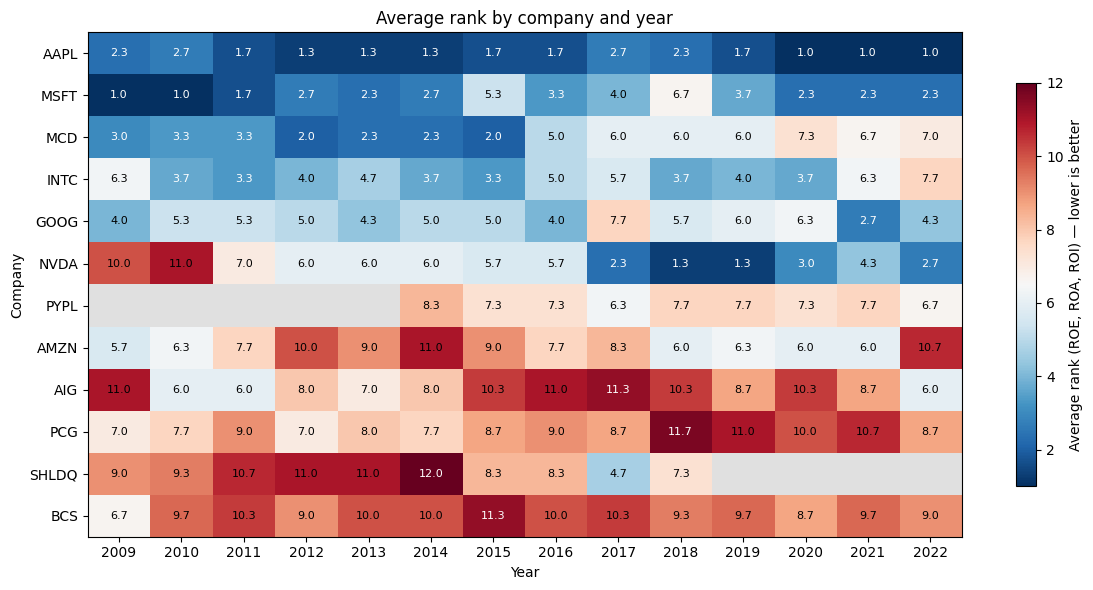

In [ ]:
# 1. Add average rank (roe_rank, roa_rank, roi_rank already exist)
efficiency_df['avg_rank'] = (efficiency_df['roe_rank'] + efficiency_df['roa_rank'] + efficiency_df['roi_rank']) / 3

# 2. Pivot into a Company x Year grid
pivot = efficiency_df.pivot(index='company', columns='year', values='avg_rank')

# 3. Sort rows by each company's overall average rank (best first)
row_order = pivot.mean(axis=1).sort_values().index
pivot = pivot.loc[row_order]

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 6))

masked = np.ma.masked_invalid(pivot.values)

vmin = np.nanmin(pivot.values)
vmax = np.nanmax(pivot.values)

im = ax.imshow(masked, cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
im.cmap.set_bad(color='#e0e0e0')

# 5. Axis labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=0)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# 6. Annotate each cell with the rank value
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            if val < 4 or val > 11:
              text_color = 'white'
            else:
              text_color = 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                     color=text_color, fontsize=8)

# 7. Colorbar + titles
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Average rank (ROE, ROA, ROI) — lower is better')

ax.set_title('Average rank by company and year')
ax.set_xlabel('Year')
ax.set_ylabel('Company')

plt.tight_layout()
plt.show()

# Where ROE and ROA Rankings Disagree

When a company's ROE rank is much better than its ROA rank, that's usually a leverage effect (debt inflating equity returns), not operating strength.

In [ ]:
sql_query4 = """
SELECT
    Company AS company,
    Year AS year,
    ROE AS roe,
    ROA AS roa,
    RANK() OVER (PARTITION BY Year ORDER BY ROE DESC) AS roe_rank,
    RANK() OVER (PARTITION BY Year ORDER BY ROA DESC) AS roa_rank,
    RANK() OVER (PARTITION BY Year ORDER BY ROE DESC)
        - RANK() OVER (PARTITION BY Year ORDER BY ROA DESC) AS rank_gap
FROM 'Financial Report'
WHERE Year BETWEEN 2009 AND 2022
ORDER BY Year, roe_rank;
"""
roa_vs_roe_df = pd.read_sql_query(sql_query4, conn)
roa_vs_roe_df.head(20).style.format({
    'roe': '{:,.2f}',
    'roa': '{:,.2f}'
})

,company,year,roe,roa,roe_rank,roa_rank,rank_gap
0,MSFT,2009,36.83,18.71,1,1,0
1,MCD,2009,32.43,15.06,2,4,-2
2,AAPL,2009,26.03,17.34,3,2,1
3,BCS,2009,19.53,0.83,4,8,-4
4,GOOG,2009,18.11,16.10,5,3,2
5,AMZN,2009,17.16,6.53,6,6,0
6,PCG,2009,11.66,2.87,7,7,0
7,INTC,2009,10.48,8.23,8,5,3
8,SHLDQ,2009,1.02,0.39,9,9,0
9,NVDA,2009,-1.25,-0.90,10,10,0


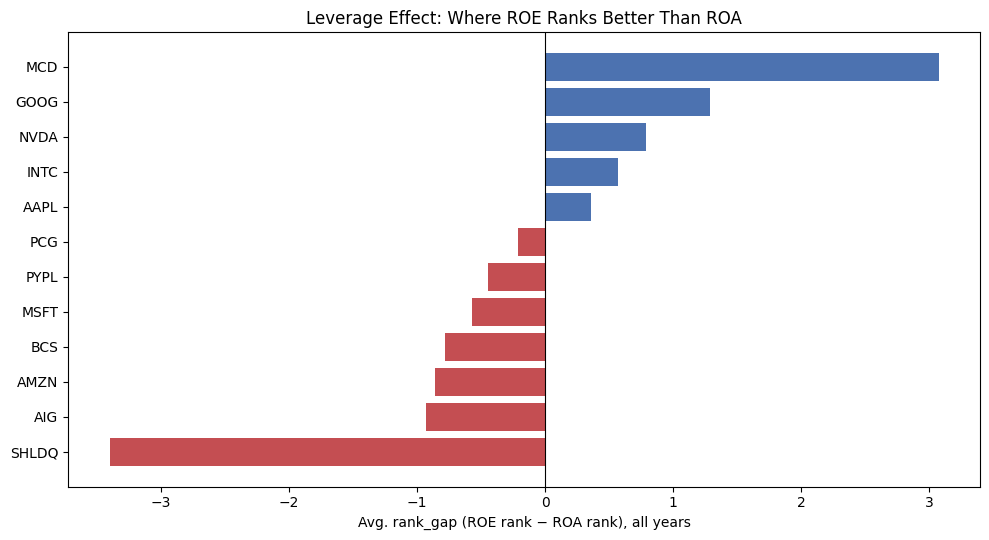

In [ ]:
avg_gap = roa_vs_roe_df.groupby('company')['rank_gap'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in avg_gap.values]
ax.barh(avg_gap.index, avg_gap.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Avg. rank_gap (ROE rank − ROA rank), all years')
ax.set_title('Leverage Effect: Where ROE Ranks Better Than ROA')
plt.tight_layout()
plt.show()

# Debt/Equity Trend Over Time

 Is each company's leverage rising or falling year over year?

In [ ]:
sql_query5 = """
SELECT
    Company AS company,
    Year AS year,
    "Debt/Equity Ratio" AS debt_equity,
    LAG("Debt/Equity Ratio") OVER (PARTITION BY Company ORDER BY Year) AS prev_debt_equity,
    ROUND("Debt/Equity Ratio" - LAG("Debt/Equity Ratio") OVER (PARTITION BY Company ORDER BY Year), 4) AS de_change
FROM 'Financial Report'
ORDER BY Company, Year;
"""
debt_trend_df = pd.read_sql_query(sql_query5, conn)
debt_trend_df.head(20).style.format({
    'debt_equity': '{:,.2f}%',
    'prev_debt_equity': '{:,.2f}%',
    'de_change': '{:,.2f}%'
})

,company,year,debt_equity,prev_debt_equity,de_change
0,AAPL,2009,0.00%,nan%,nan%
1,AAPL,2010,0.00%,0.00%,0.00%
2,AAPL,2011,0.00%,0.00%,0.00%
3,AAPL,2012,0.00%,0.00%,0.00%
4,AAPL,2013,0.14%,0.00%,0.14%
5,AAPL,2014,0.32%,0.14%,0.18%
6,AAPL,2015,0.54%,0.32%,0.22%
7,AAPL,2016,0.68%,0.54%,0.14%
8,AAPL,2017,0.86%,0.68%,0.18%
9,AAPL,2018,1.07%,0.86%,0.21%


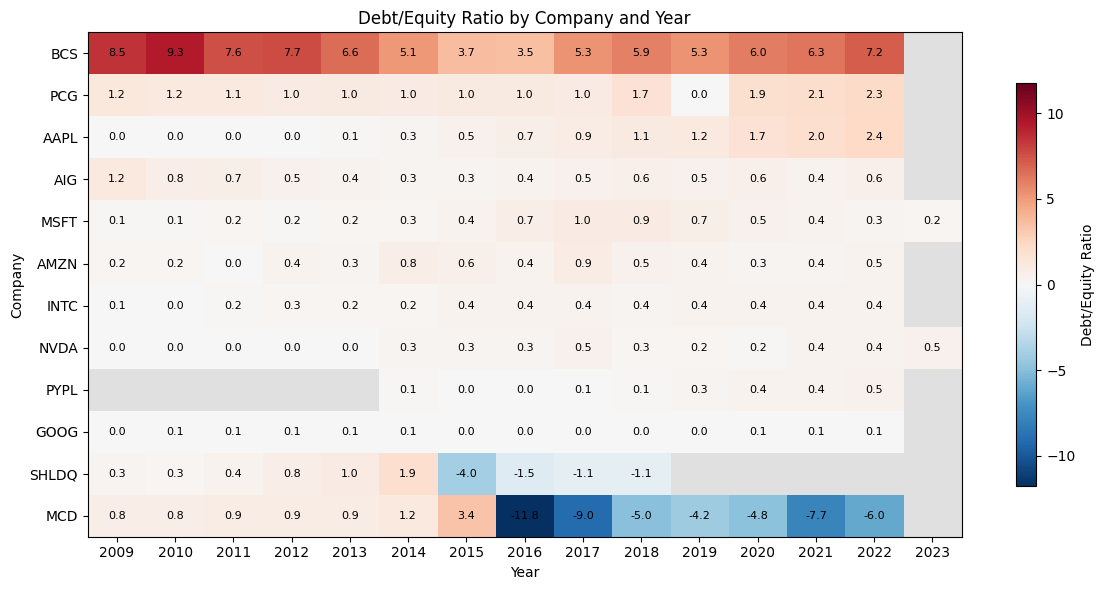

In [ ]:
pivot_de = debt_trend_df.pivot(index='company', columns='year', values='debt_equity')
row_order = pivot_de.mean(axis=1, skipna=True).sort_values(ascending=False).index
pivot_de = pivot_de.loc[row_order]

fig, ax = plt.subplots(figsize=(12, 6))
masked = np.ma.masked_invalid(pivot_de.values)
vmax = np.nanmax(np.abs(pivot_de.values))
im = ax.imshow(masked, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
im.cmap.set_bad(color='#e0e0e0')

ax.set_xticks(range(len(pivot_de.columns)))
ax.set_xticklabels(pivot_de.columns, rotation=0)
ax.set_yticks(range(len(pivot_de.index)))
ax.set_yticklabels(pivot_de.index)

for i in range(pivot_de.shape[0]):
    for j in range(pivot_de.shape[1]):
        val = pivot_de.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Debt/Equity Ratio')
ax.set_title('Debt/Equity Ratio by Company and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Company')
plt.tight_layout()
plt.show()


# Earnings Quality (Cash Flow vs. Net Income)

Is reported profit backed by actual cash, or just accounting income? A company whose operating cash flow reliably exceeds net income is generally considered to have higher-quality earnings.




In [ ]:
sql_query6 = """
SELECT
    Company AS company,
    Year AS year,
    "Net Income" AS net_income,
    "Cash Flow from Operating" AS operating_cf,
    ROUND("Cash Flow from Operating" - "Net Income", 2) AS cf_minus_ni,
    ROUND("Cash Flow from Operating" * 1.0 / "Net Income", 4) AS cf_to_ni_ratio
FROM 'Financial Report'
WHERE "Net Income" > 0
ORDER BY cf_to_ni_ratio ASC;
"""
earnings_quality_df = pd.read_sql_query(sql_query6, conn)
earnings_quality_df.head(20).style.format({
    'net_income': '{:,.2f}',
    'operating_cf': '{:,.2f}',
    'cf_minus_ni': '{:,.2f}',
    'cf_to_ni_ratio': '{:,.4f}'
})

,company,year,net_income,operating_cf,cf_minus_ni,cf_to_ni_ratio
0,BCS,2013,846.56,"-39,392.27","-40,238.83",-46.5323
1,BCS,2019,"4,180.57","-15,699.49","-19,880.06",-3.7553
2,AIG,2019,"3,326.00","-1,807.00","-5,133.00",-0.5433
3,AIG,2011,"19,810.00",-81.00,"-19,891.00",-0.0041
4,AIG,2022,"10,247.00","4,207.00","-6,040.00",0.4106
5,AIG,2013,"9,085.00","5,865.00","-3,220.00",0.6456
6,AIG,2014,"7,529.00","5,007.00","-2,522.00",0.6650
7,AIG,2021,"9,359.00","6,279.00","-3,080.00",0.6709
8,NVDA,2019,"4,141.00","3,743.00",-398.00,0.9039
9,SHLDQ,2011,133.00,123.00,-10.00,0.9248


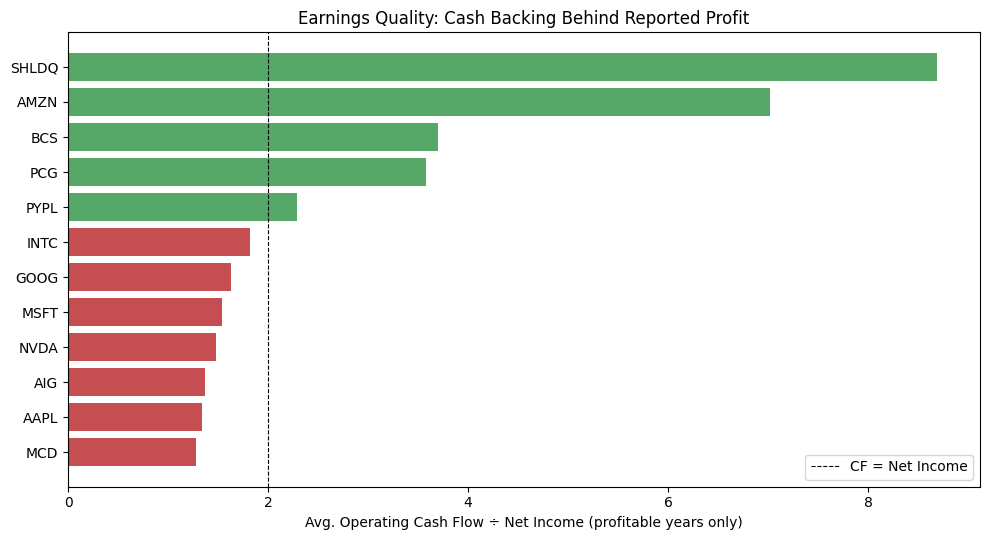

In [ ]:
avg_cf_ni = earnings_quality_df.groupby('company')['cf_to_ni_ratio'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ['#C44E52' if v < 2 else '#55A868' for v in avg_cf_ni.values]
ax.barh(avg_cf_ni.index, avg_cf_ni.values, color=colors)
ax.axvline(2, color='black', linewidth=0.8, linestyle='--', label='CF = Net Income')
ax.set_xlabel('Avg. Operating Cash Flow ÷ Net Income (profitable years only)')
ax.set_title('Earnings Quality: Cash Backing Behind Reported Profit')
ax.legend()
plt.tight_layout()
plt.show()

# EBITDA Margin Ranking

Who converts revenue into EBITDA most efficiently, and how does that ranking shift year to year?

In [ ]:
sql_query7 = """
SELECT
    Company AS company,
    Year AS year,
    Revenue AS revenue,
    EBITDA AS ebitda,
    ROUND(EBITDA * 1.0 / Revenue * 100, 4) AS ebitda_margin,
    RANK() OVER (PARTITION BY Year ORDER BY (EBITDA * 1.0 / Revenue) DESC) AS ebitda_margin_rank
FROM 'Financial Report'
WHERE Year BETWEEN 2009 AND 2022
ORDER BY Year, ebitda_margin_rank;
"""
ebitda_margin_df = pd.read_sql_query(sql_query7, conn)
ebitda_margin_df.head(20).style.format({
    'revenue': '{:,.2f}',
    'ebitda': '{:,.2f}',
    'ebitda_margin': '{:,.4f}'
})

,company,year,revenue,ebitda,ebitda_margin,ebitda_margin_rank
0,GOOG,2009,"23,651.00","9,836.00",41.5881,1
1,MSFT,2009,"58,437.00","22,925.00",39.2303,2
2,AIG,2009,"75,447.00","27,765.00",36.8007,3
3,MCD,2009,"22,744.70","8,057.20",35.4245,4
4,INTC,2009,"35,127.00","10,763.00",30.6402,5
5,PCG,2009,"13,399.00","4,051.00",30.2336,6
6,AAPL,2009,"42,905.00","12,474.00",29.0735,7
7,AMZN,2009,"24,509.00","1,507.00",6.1488,8
8,NVDA,2009,"3,424.86",114.32,3.3380,9
9,SHLDQ,2009,"46,770.00","1,283.00",2.7432,10


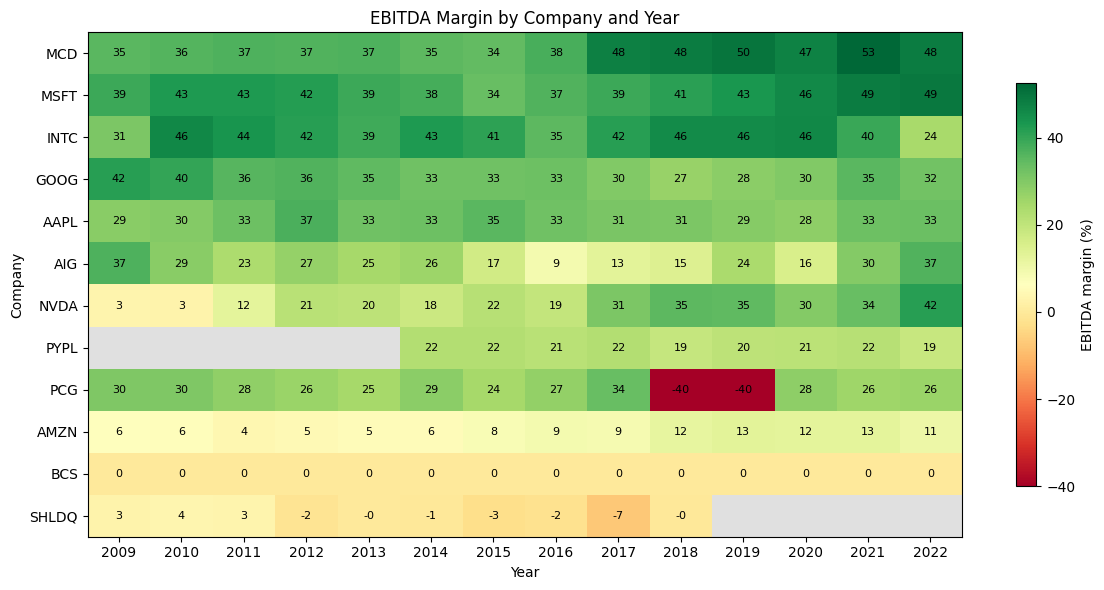

In [ ]:
pivot_margin = ebitda_margin_df.pivot(index='company', columns='year', values='ebitda_margin')
row_order = pivot_margin.mean(axis=1).sort_values(ascending=False).index
pivot_margin = pivot_margin.loc[row_order]

fig, ax = plt.subplots(figsize=(12, 6))
masked = np.ma.masked_invalid(pivot_margin.values)
im = ax.imshow(masked, cmap='RdYlGn', aspect='auto')
im.cmap.set_bad(color='#e0e0e0')

ax.set_xticks(range(len(pivot_margin.columns)))
ax.set_xticklabels(pivot_margin.columns, rotation=0)
ax.set_yticks(range(len(pivot_margin.index)))
ax.set_yticklabels(pivot_margin.index)

for i in range(pivot_margin.shape[0]):
    for j in range(pivot_margin.shape[1]):
        val = pivot_margin.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('EBITDA margin (%)')
ax.set_title('EBITDA Margin by Company and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Company')
plt.tight_layout()
plt.show()



# Market Cap-to-Earnings Proxy

 How is the market pricing each dollar of net income? (Market Cap / Net Income, in $M terms — a rough stand-in for a P/E ratio since this dataset doesn't include share price directly.)

In [ ]:
sql_query8 = """
SELECT
    Company AS company,
    Year AS year,
    "Market Cap(in B USD)" AS market_cap,
    "Net Income" AS net_income,
    ROUND(("Market Cap(in B USD)" * 1000) / "Net Income", 2) AS market_cap_to_ni,
    RANK() OVER (PARTITION BY Year ORDER BY ("Market Cap(in B USD)" * 1000) / "Net Income" DESC) AS valuation_rank
FROM 'Financial Report'
WHERE Year BETWEEN 2009 AND 2022 AND "Net Income" > 0
ORDER BY Year, valuation_rank;
"""
valuation_proxy_df = pd.read_sql_query(sql_query8, conn)

In [ ]:
valuation_summary = (
    valuation_proxy_df.groupby('company')['market_cap_to_ni']
    .agg(mean='mean', median='median', std='std')
    .sort_values('median', ascending=False)
)
valuation_summary.style.format('{:,.2f}')


,mean,median,std
company,,,
AMZN,188.42,79.06,209.20
PYPL,46.39,48.73,11.14
SHLDQ,76.63,34.98,80.50
NVDA,55.30,34.09,48.15
GOOG,27.89,25.93,9.34
MSFT,25.20,24.05,11.85
MCD,24.23,23.96,6.97
PCG,20.45,19.24,8.03
AAPL,19.30,17.17,8.02


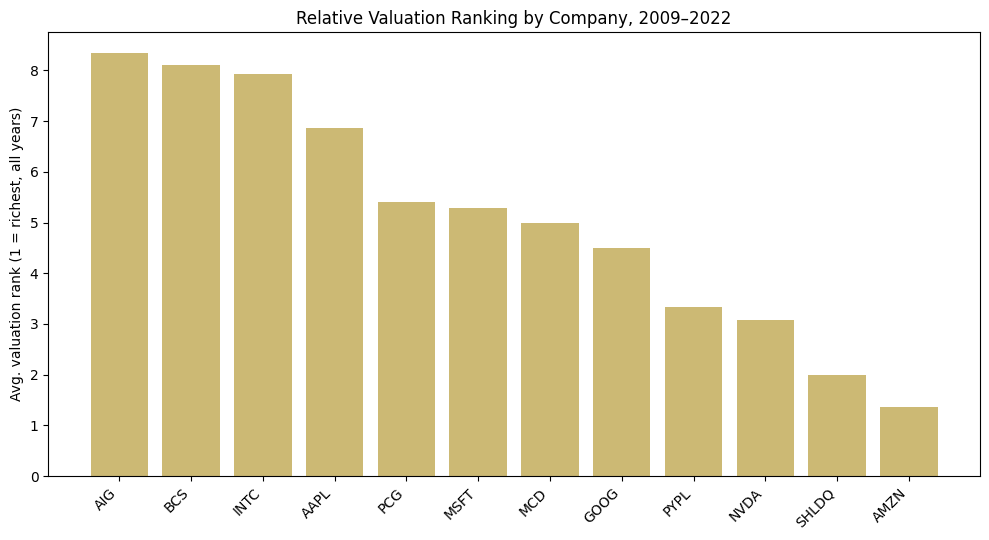

In [ ]:
avg_valuation_rank = valuation_proxy_df.groupby('company')['valuation_rank'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(avg_valuation_rank.index, avg_valuation_rank.values, color='#CCB974')
ax.set_ylabel('Avg. valuation rank (1 = richest, all years)')
ax.set_title('Relative Valuation Ranking by Company, 2009–2022')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Real (Inflation-Adjusted) Revenue Growth

Once US inflation is stripped out, is a company's revenue growth real, or just nominal?

In [ ]:
sql_query9 = """
SELECT
    Company AS company,
    Year AS year,
    Revenue AS revenue,
    "Inflation Rate(in US)" AS inflation_rate,
    ROUND((Revenue - LAG(Revenue) OVER (PARTITION BY Company ORDER BY Year)) * 1.0
        / LAG(Revenue) OVER (PARTITION BY Company ORDER BY Year) * 100, 4) AS nominal_growth_pct,
    ROUND(
        ((Revenue - LAG(Revenue) OVER (PARTITION BY Company ORDER BY Year)) * 1.0
        / LAG(Revenue) OVER (PARTITION BY Company ORDER BY Year) * 100)
        - "Inflation Rate(in US)", 4
    ) AS real_growth_pct
FROM 'Financial Report'
ORDER BY Company, Year;
"""
real_growth_df = pd.read_sql_query(sql_query9, conn)
real_growth_df.head(20).style.format({
    'revenue': '{:,.2f}',
    'inflation_rate': '{:,.2f}%',
    'nominal_growth_pct': '{:,.2f}%',
    'real_growth_pct': '{:,.2f}%'
})

,company,year,revenue,inflation_rate,nominal_growth_pct,real_growth_pct
0,AAPL,2009,"42,905.00",-0.36%,nan%,nan%
1,AAPL,2010,"65,225.00",1.64%,52.02%,50.38%
2,AAPL,2011,"108,249.00",3.16%,65.96%,62.81%
3,AAPL,2012,"156,508.00",2.07%,44.58%,42.51%
4,AAPL,2013,"170,910.00",1.46%,9.20%,7.74%
5,AAPL,2014,"182,795.00",1.62%,6.95%,5.33%
6,AAPL,2015,"233,715.00",0.12%,27.86%,27.74%
7,AAPL,2016,"215,639.00",1.26%,-7.73%,-9.00%
8,AAPL,2017,"229,234.00",2.13%,6.30%,4.17%
9,AAPL,2018,"265,595.00",2.44%,15.86%,13.42%


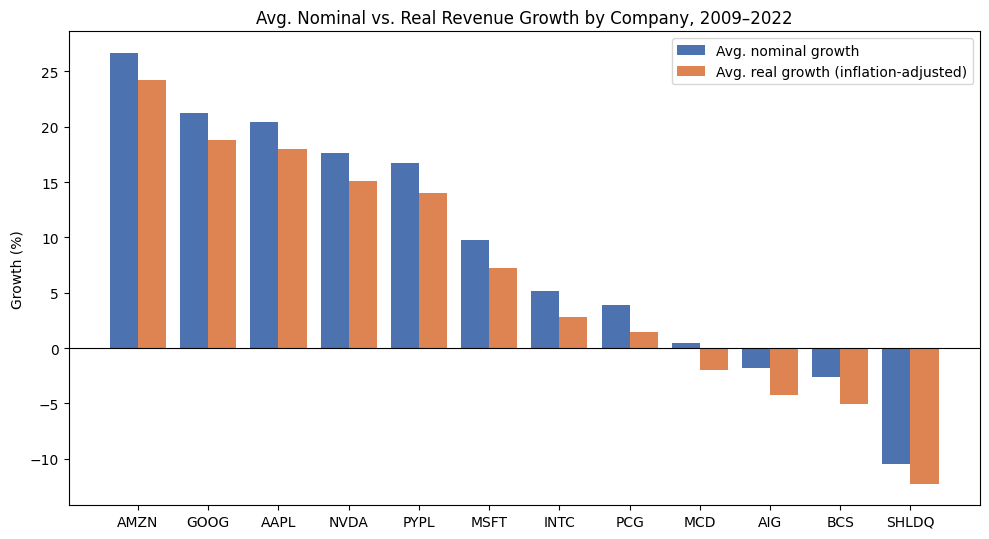

In [ ]:
avg_growth_by_company = (
    real_growth_df.dropna(subset=['real_growth_pct'])
    .groupby('company')[['nominal_growth_pct', 'real_growth_pct']]
    .mean()
    .sort_values('real_growth_pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(avg_growth_by_company))
width = 0.4
ax.bar(x - width/2, avg_growth_by_company['nominal_growth_pct'], width, label='Avg. nominal growth', color='#4C72B0')
ax.bar(x + width/2, avg_growth_by_company['real_growth_pct'], width, label='Avg. real growth (inflation-adjusted)', color='#DD8452')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(avg_growth_by_company.index)
ax.set_ylabel('Growth (%)')
ax.set_title('Avg. Nominal vs. Real Revenue Growth by Company, 2009–2022')
ax.legend()
plt.tight_layout()
plt.show()

# Composite Financial Quality Score

 Combining ROE rank, ROA rank, and cash-flow-quality rank into one score, which company is the most consistently strong performer across the whole dataset — not just in any single metric?

In [ ]:
sql_query10 = """
WITH ranked AS (
    SELECT
        Company AS company,
        Year AS year,
        ROE AS roe,
        ROA AS roa,
        "Net Income" AS net_income,
        "Cash Flow from Operating" AS operating_cf,
        RANK() OVER (PARTITION BY Year ORDER BY ROE DESC) AS roe_rank,
        RANK() OVER (PARTITION BY Year ORDER BY ROA DESC) AS roa_rank,
        RANK() OVER (
            PARTITION BY Year
            ORDER BY ("Cash Flow from Operating" * 1.0 / "Net Income") DESC
        ) AS cf_quality_rank
    FROM 'Financial Report'
    WHERE "Net Income" > 0
)
SELECT
    company,
    year,
    roe,
    roa,
    ROUND(operating_cf * 1.0 / net_income, 4) AS cf_to_ni_ratio,
    roe_rank,
    roa_rank,
    cf_quality_rank,
    ROUND((roe_rank + roa_rank + cf_quality_rank) / 3.0, 2) AS composite_score,
    RANK() OVER (
        PARTITION BY year
        ORDER BY (roe_rank + roa_rank + cf_quality_rank) ASC
    ) AS composite_rank
FROM ranked
WHERE year BETWEEN 2009 AND 2022
ORDER BY year, composite_rank;
"""
composite_quality_df = pd.read_sql_query(sql_query10, conn)
composite_quality_df.head(20).style.format({
    'roe': '{:,.2f}%',
    'roa': '{:,.2f}%',
    'cf_to_ni_ratio': '{:,.4f}',
    'composite_score': '{:,.2f}'
})

,company,year,roe,roa,cf_to_ni_ratio,roe_rank,roa_rank,cf_quality_rank,composite_score,composite_rank
0,MSFT,2009,36.83%,18.71%,1.3067,1,1,7,3.00,1
1,MCD,2009,32.43%,15.06%,1.2637,2,4,8,4.67,2
2,AAPL,2009,26.03%,17.34%,1.2336,3,2,9,4.67,2
3,BCS,2009,19.53%,0.83%,11.9180,4,8,2,4.67,2
4,GOOG,2009,18.11%,16.10%,1.4288,5,3,6,4.67,2
5,AMZN,2009,17.16%,6.53%,3.6508,6,6,3,5.00,6
6,INTC,2009,10.48%,8.23%,2.5566,8,5,4,5.67,7
7,PCG,2009,11.66%,2.87%,2.4910,7,7,5,6.33,8
8,SHLDQ,2009,1.02%,0.39%,18.7170,9,9,1,6.33,8
9,MSFT,2010,40.63%,21.79%,1.2832,1,1,9,3.67,1


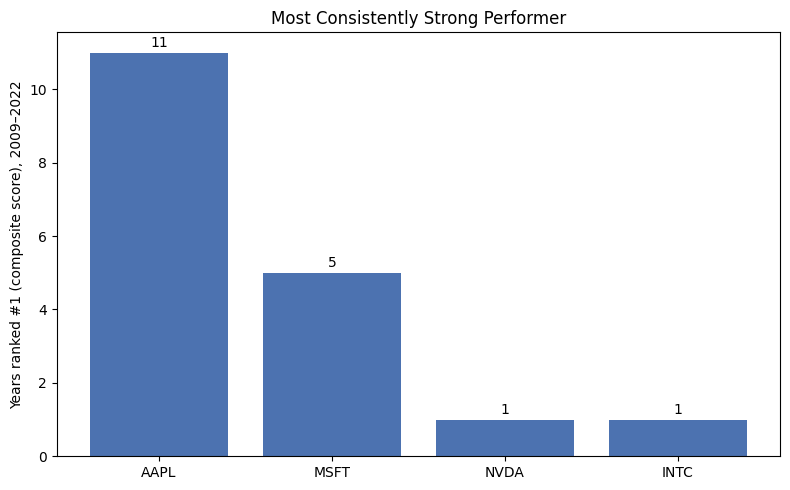

In [ ]:
wins = composite_quality_df[composite_quality_df['composite_rank'] == 1]['company'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(wins.index, wins.values, color='#4C72B0')
ax.set_ylabel('Years ranked #1 (composite score), 2009–2022')
ax.set_title('Most Consistently Strong Performer')
for i, v in enumerate(wins.values):
    ax.text(i, v + 0.15, str(v), ha='center')
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('exports', exist_ok=True)

exports = {
    'raw_financial_data': df_raw,
    '01_yoy_revenue_growth': yoy_growth_df,
    '02_profitability_rank': profitability_rank,
    '03_efficiency_roe_roa_roi': efficiency_df,
    '04_roe_vs_roa_rank_gap': roa_vs_roe_df,
    '05_debt_equity_trend': debt_trend_df,
    '06_earnings_quality': earnings_quality_df,
    '07_ebitda_margin': ebitda_margin_df,
    '08_valuation_proxy': valuation_proxy_df,
    '09_real_vs_nominal_growth': real_growth_df,
    '10_composite_quality_score': composite_quality_df,
}

for name, frame in exports.items():
    frame.to_csv(f'exports/{name}.csv', index=False)